Load Data frame and convert Trip Start Timestamp to date time

In [1]:
import pandas as pd

df = pd.read_csv("data/taxi_pickups_area.csv")

x = pd.to_datetime(df['Trip Start Timestamp'])

df.drop(columns='Trip Start Timestamp', inplace=True)

Plot Original Pickup Community Area_1 as example

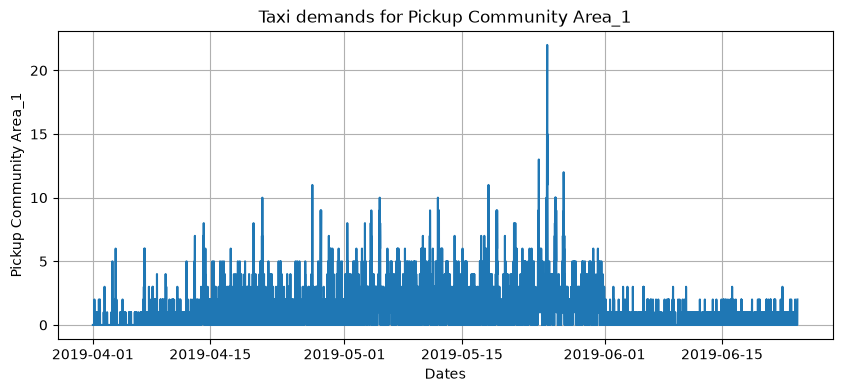

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(x, df['Pickup Community Area_1'])

plt.xlabel("Dates")
plt.ylabel("Pickup Community Area_1")
plt.title("Taxi demands for Pickup Community Area_1")
plt.grid(True)
plt.show()
# areas = df.columns.to_list()
# for area in areas:
#     plt.figure(figsize=(12, 5))
#     plt.plot(x, df[area], linestyle="-")

#     plt.xlabel("Interval 15 days")
#     plt.ylabel(area)
#     plt.title(f"Taxi demand over time - {area}")
#     plt.grid(True)
#     plt.tight_layout()
#     plt.show()

Apply Seasonal-Trend Decomposition LOESS (STL) to split components from Pickup Community Area_1

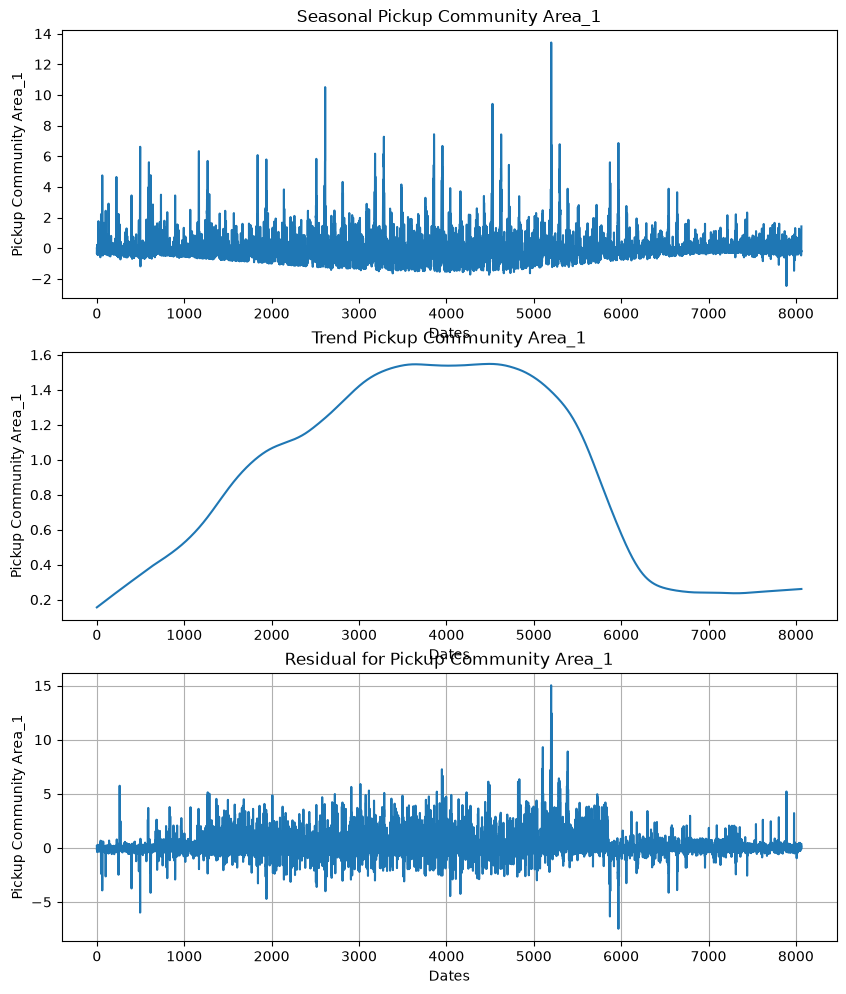

In [16]:
from statsmodels.tsa.seasonal import STL

stl = STL(df['Pickup Community Area_1'], robust=True, period=672)

result = stl.fit()

seasonal, trend, resid = result.seasonal, result.trend, result.resid

plt.figure(figsize=(10, 16))

plt.subplot(4,1,1)
plt.plot(seasonal)
plt.xlabel("Dates")
plt.ylabel("Pickup Community Area_1")
plt.title("Seasonal Pickup Community Area_1")

plt.subplot(4,1,2)
plt.plot(trend)
plt.xlabel("Dates")
plt.ylabel("Pickup Community Area_1")
plt.title("Trend Pickup Community Area_1")

plt.subplot(4,1,3)
plt.plot(resid)
plt.xlabel("Dates")
plt.ylabel("Pickup Community Area_1")
plt.title("Residual for Pickup Community Area_1")

plt.grid(True)
plt.show()